# Wavelet
*  Jose Gonzalez Lopez
*  Mykola Liashuha

# Introduction
In this notebook we will be applying some denoising techniques in the wavelet domain. We will first create some noise data as we did on the previous exercise and then we will try to recover the original data by applying hard or soft thresholding to the image.

# Imports

In [1]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise

from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

In [2]:
from __future__ import division
from nt_toolbox.general import *
from nt_toolbox.signal import *
%load_ext autoreload
%autoreload 2
%pylab inline
%matplotlib inline

Populating the interactive namespace from numpy and matplotlib


/home/mykola/anaconda3/envs/nets/lib/python3.6/site-packages/IPython/core/magics/pylab.py:160: UserWarning: pylab import has clobbered these variables: ['pylab']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"


# Auxiliar Functions

In [3]:
'''
Signal-to-noise ratio
x: original signal
y: changed(noisy) signal
'''
def snr(x, y):
#     return 20*np.log10(np.linalg.norm(x)/np.linalg.norm(x-y))
    return 20*np.log10(np.sqrt(np.power(x, 2).sum())/np.sqrt(np.power(x-y, 2).sum()))

In [77]:
'''
Hard thesholding operator
T: threshold value
alpha: image in wavelet domain
'''
def hard_operator(T, alpha):
    return alpha*(abs(alpha)>T)

'''
Soft thresholding operator
u: image in wavelet domain
t: threshold value
'''
def thresh_soft(u,t):
    return maximum(1-t/abs(u), 0)*u

# Loading data

Below we load the image, but most importatnly we keep it in range [0,1]

In [4]:
img = cv2.imread('barbara.jpg')
gray = np.array(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
gray = gray / 255.


In order to show further the process of denoising we create image with different levels of noise.

In [72]:
stds = [0.42,0.25, 0.16, 0.08, 0.04]#[130,70,40, 24,13]
noisy_imgs=[]
for std in stds:
    noise = numpy.random.normal(0, 1, size=gray.shape)
    img_noise = gray + std*noise
    noisy_imgs.append(img_noise)

# Hard thresholding in wavelet domain

Below you are able to see how the values woulb be affected by filter with hrad threshold.

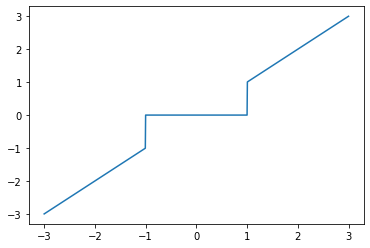

In [80]:
T = 1
alpha = np.linspace(-3,3,1000);

plt.plot(alpha, alpha*(np.abs(alpha)>T))

Then we define parameters for othogonal wavelet transoform.

In [81]:
h = [0, .482962913145, .836516303738, .224143868042, -.129409522551]
h = h/norm(h)
Jmin = 2

We will add some noisy to the image and define the threshold value for hard-threshold filter.

In [82]:
sigma = 0.16

noise = numpy.random.normal(0, 1, size=gray.shape)
img_noise = gray + sigma*noise
T = 3*sigma


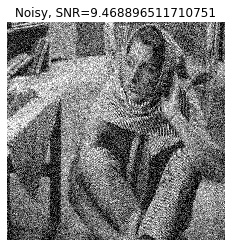

In [83]:
imageplot(clamp(img_noise), 'Noisy, SNR=' + str(snr(gray,img_noise)) )

As far as you see the image looks ihghly noisy. Therefore in order to perform denoising, we are going to apply wavelet orthogonal transform to the image and transform it to wavelet domain.

In [84]:
a = perform_wavortho_transf(img_noise,Jmin,+1,h)

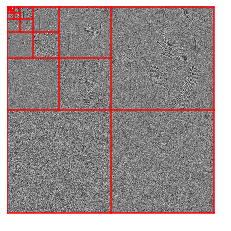

In [85]:
plot_wavelet(a,Jmin);

Having image in wavelet domain we are going to apply hard thresholding to obtained values.

In [86]:

aT = thresh_hard(a, T)

array([[0.24576205, 0.        , 0.21929783, ..., 0.5       , 0.5       ,
        0.5       ],
       [0.16452091, 0.60647824, 1.        , ..., 0.5       , 0.5       ,
        0.5       ],
       [0.50586394, 0.74627864, 0.72583057, ..., 0.5       , 0.5       ,
        0.5       ],
       ...,
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ],
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ],
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ]])

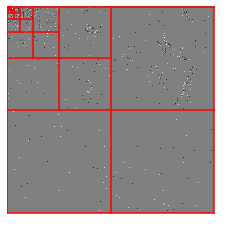

In [87]:
plot_wavelet(aT,Jmin)

And after applying hard thresholding we are to to transofrm image back to its original domain.

In [88]:
fHard = perform_wavortho_transf(aT,Jmin,-1,h)

Original Image


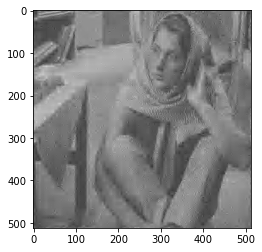

In [89]:
print('Original Image')
plt.imshow(fHard, cmap='gray')
plt.show()

Noisy image


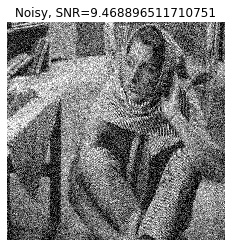

In [90]:
print('Noisy image')
imageplot(clamp(img_noise), 'Noisy, SNR=' + str(snr(gray,img_noise)) )

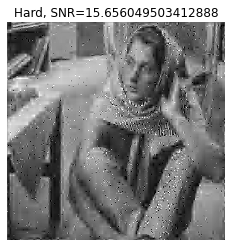

In [91]:
print('Denosied image')
imageplot(clamp(fHard), 'Hard, SNR=' + str(snr(gray,fHard)) )

As you see from the experiment, the denosied image has much less noise (since Signal-noise-ratio increased).

Moreover, in order to show that the denoising pipeline works we are going to test on several images with different level of noise.

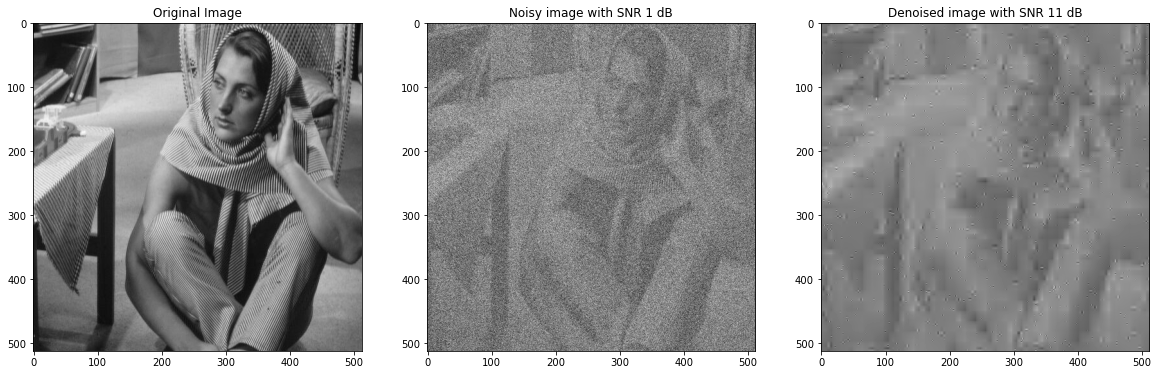

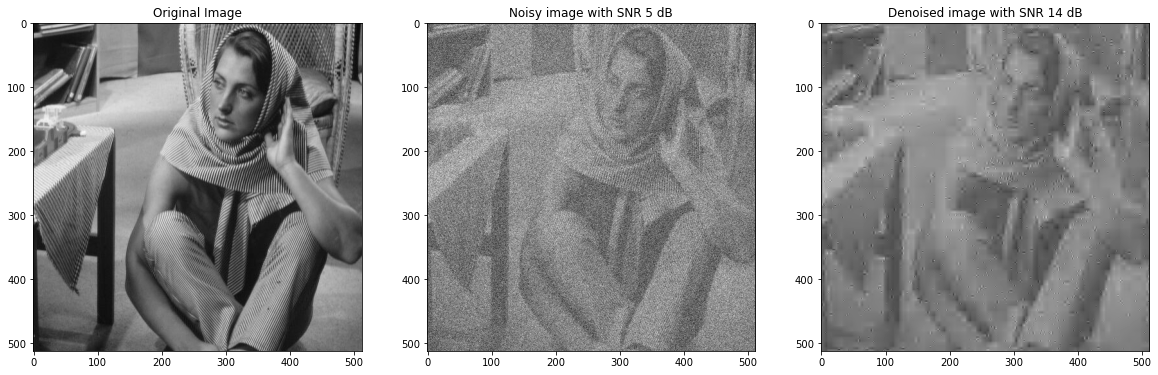

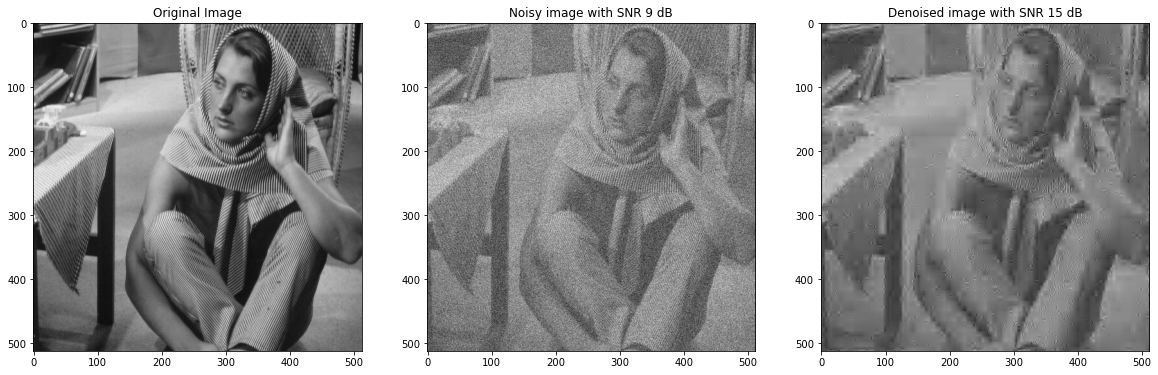

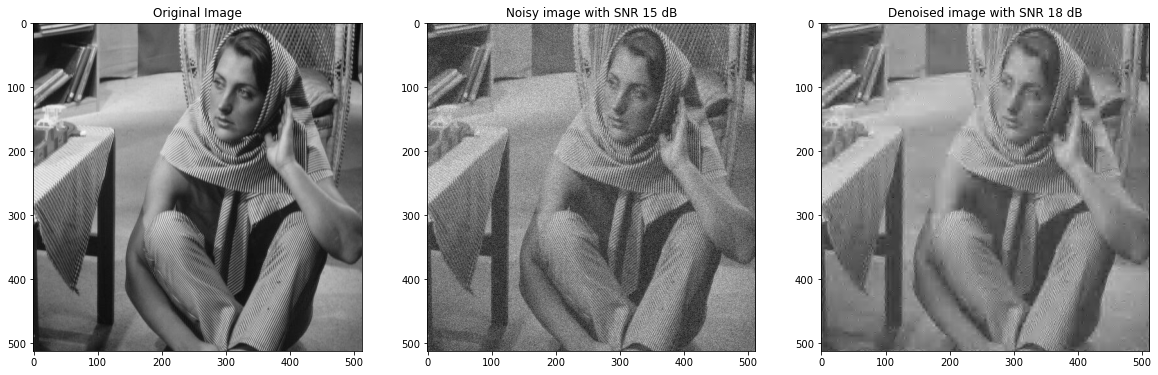

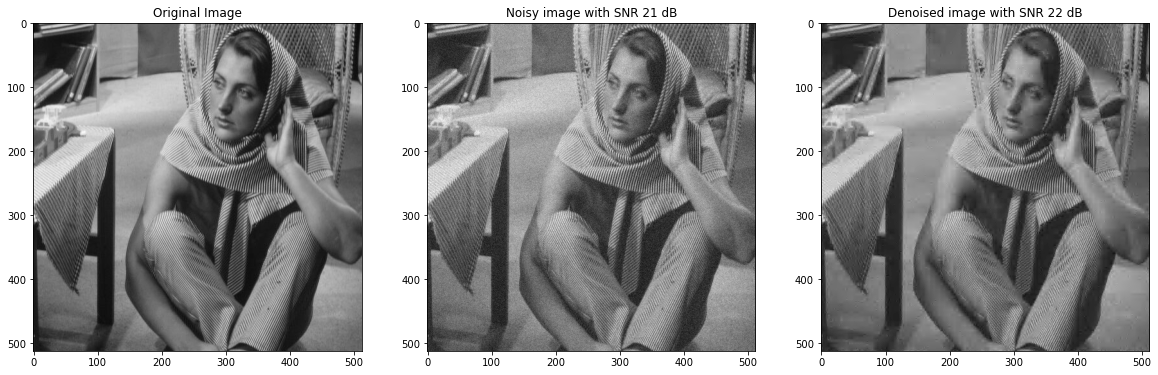

In [33]:

for i, noisy_image in enumerate(noisy_imgs):
    std = stds[i]
    T = 3*std
    
    a = perform_wavortho_transf(noisy_image,Jmin,+1,h)
    aT = thresh_hard(a, T)
    fHard = perform_wavortho_transf(aT,Jmin,-1,h)
    
    fig, axs = plt.subplots(1, 3)
    fig.set_figheight(20)
    fig.set_figwidth(20)
    axs[0].imshow(gray,cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].imshow(noisy_image,cmap='gray')
    axs[1].set_title('Noisy image'+f' with SNR {int(snr(gray,noisy_image))} dB')
    axs[2].imshow(fHard,cmap='gray')
    axs[2].set_title('Denoised image'+f' with SNR {int(snr(gray,fHard))} dB')
    plt.show()

# Soft thresholding in wavelet domain

As well, we are going to provide another way for thresholding the image in wavelet domain - Soft-thresholding. Belowe you can see plot how values are going to be affected by aplying soft-thresholding.

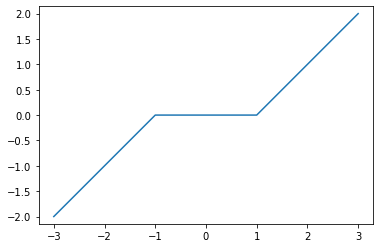

In [49]:

alpha = linspace(-3,3,1000)
plot(alpha, thresh_soft(alpha,1))
axis('equal');

Below we are going perform another experiment applying soft-thresholding to an image. And we start from creating noisy image.

In [92]:
sigma = 0.08

noise = numpy.random.normal(0, 1, size=gray.shape)
img_noise = gray + sigma*noise

T = (1.5)*sigma

Futher we are going to applying soft-thresholding to an image in wavelet domain and transofrm it back to ususal usual domain.

In [64]:
aT = thresh_soft(a,T)
aT[:2^Jmin:,:2^Jmin:] = a[:2^Jmin:,:2^Jmin:]
fSoft = perform_wavortho_transf(aT,Jmin,-1,h)

Nosiy image


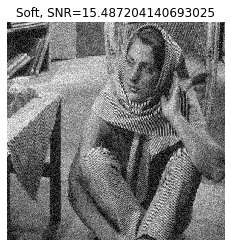

In [93]:
print('Nosiy image')
imageplot(clamp(img_noise), 'Soft, SNR=' + str(snr(gray,img_noise)) )

Denoised image


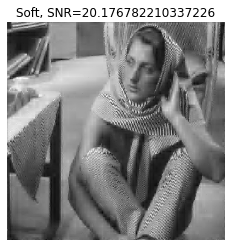

In [94]:
print('Denoised image')
imageplot(clamp(fSoft), 'Soft, SNR=' + str(snr(gray,fSoft)) )

As well as, we are going to apply soft-thresholding to images with different level of noise.

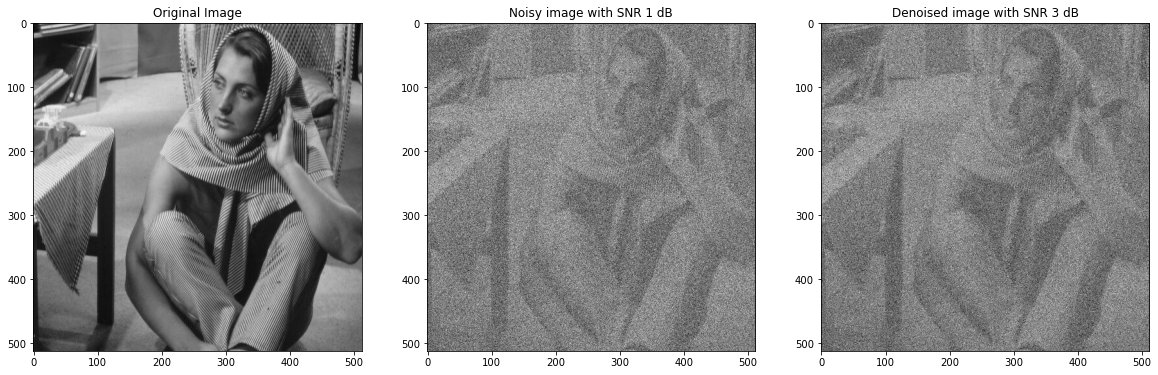

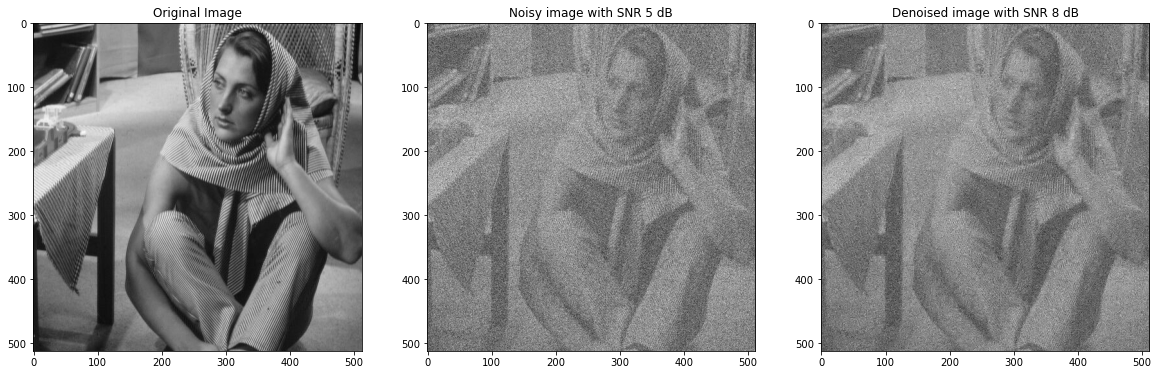

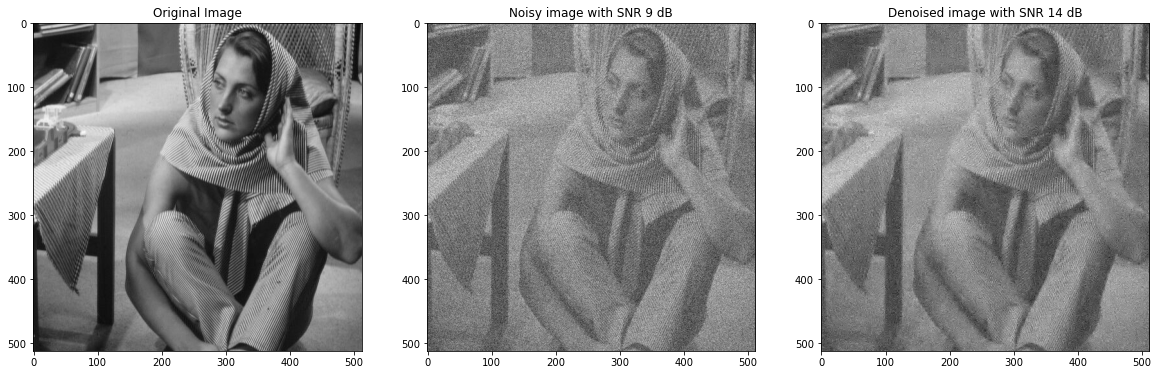

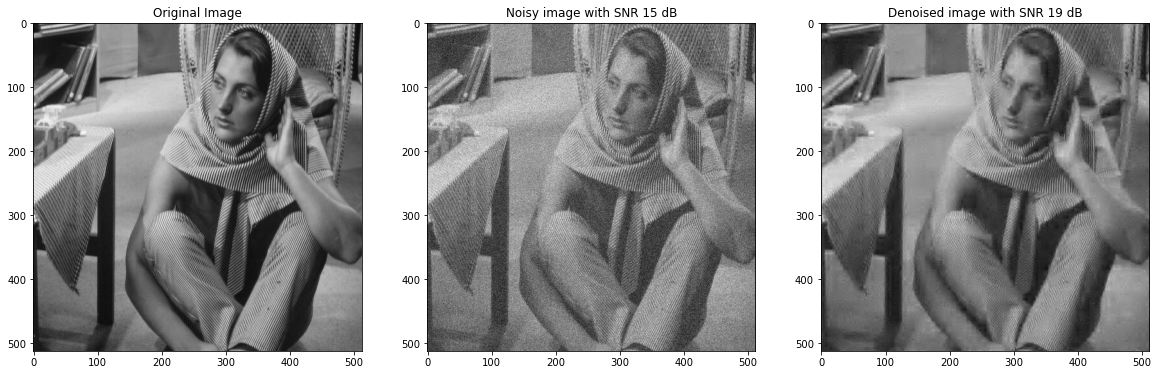

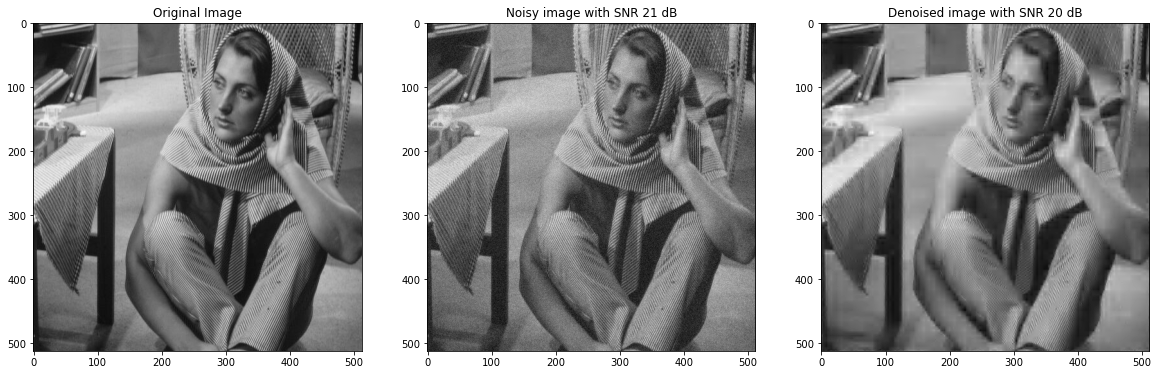

In [74]:

for i, noisy_image in enumerate(noisy_imgs):
    std = stds[i]
    T = (1.5)*sigma
    
    a = perform_wavortho_transf(noisy_image,Jmin,+1,h)
    aT = thresh_soft(a,T)
    aT[:2^Jmin:,:2^Jmin:] = a[:2^Jmin:,:2^Jmin:]
    fSoft = perform_wavortho_transf(aT,Jmin,-1,h)
    
    fig, axs = plt.subplots(1, 3)
    fig.set_figheight(20)
    fig.set_figwidth(20)
    axs[0].imshow(gray,cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].imshow(noisy_image,cmap='gray')
    axs[1].set_title('Noisy image'+f' with SNR {int(snr(gray,noisy_image))} dB')
    axs[2].imshow(fSoft,cmap='gray')
    axs[2].set_title('Denoised image'+f' with SNR {int(snr(gray,fSoft))} dB')
    plt.show()

# Finding best threshold

Below we are going to plot SNR and corresponding threshold values for hard- and soft-thresholding.

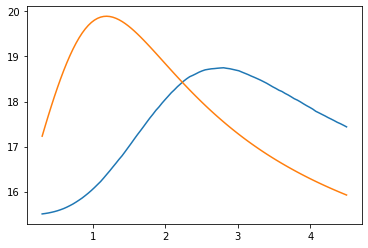

In [97]:
sigma = 0.08
ran = np.linspace(0.3, 4.5, num=100)*sigma

hard = []
soft = []

for T in ran:
    a = perform_wavortho_transf(img_noise,Jmin,+1,h)
    
    #hard
    aT = thresh_hard(a, T)
    fHard = perform_wavortho_transf(aT,Jmin,-1,h)
    hard.append(snr(gray,fHard))
    
    #soft
    aT = thresh_soft(a,T)
    aT[:2^Jmin:,:2^Jmin:] = a[:2^Jmin:,:2^Jmin:]
    fSoft = perform_wavortho_transf(aT,Jmin,-1,h)
    soft.append(snr(gray,fSoft))
    
plt.plot(ran/sigma, hard)
plt.plot(ran/sigma, soft)
plt.show()

As you can observe, we have achieved different SNR values after applying denoising with differnt threshold values. From this plot it is easy to identify best threshold parameters:


In [99]:
best_hard = np.argmax(hard)
best_soft = np.argmax(soft)
print('Best hard-thresholding parameter', ran[best_hard]/sigma)
print('Best soft-thresholding parameter', ran[best_soft]/sigma)

Best hard-thresholding parameter 2.803030303030303
Best soft-thresholding parameter 1.190909090909091


# Translation invariant denoising

One of the problems of orthoginal wavelet transform is that it is provide differnt results for the same images, but transltead ones. So it this kind of transform is not translation inavriant.

In order to overcome this drawback we are going to:
- transform image with orthogonal wavelet transform to several circle-shifted copies of an image
- apply denoising procedure to each image copy
- circle-shift denoised copied back to normal orientation
- average results from all denoised copies
- transform resulting image back to normal domain.

We would have 4 different states of circle-shif

In [100]:
m = 4

In [101]:
[dY,dX] = meshgrid(arange(0,m),arange(0,m))
delta = concatenate( (dX.reshape(m*m,1), dY.reshape(m*m,1)), axis=1)


In [131]:
def circshift(x, p):
    """
        Circular shift of an array.
    """
    y = x.copy()
    y = np.concatenate((y[p[0]::, :], y[:p[0]:, :]), axis=0)
#     if x.shape[1] > 0 and len(p) > 1:
#         y = np.concatenate((y[:, p[0]::], y[:, :p[0]:]), axis=1)
    return y

In [128]:
circshift(img_noise,delta[3,:])

(512, 512)


array([[-0.02985212,  0.1514405 ,  0.28349578, ...,  0.26973619,
         0.19008206,  0.42314127],
       [ 0.18720978,  0.20815698,  0.10399514, ...,  0.11380417,
         0.22755274,  0.47113798],
       [ 0.1057894 ,  0.07288246,  0.20335715, ...,  0.14503465,
         0.14763577,  0.40334227],
       ...,
       [ 0.19412003,  0.10217453,  0.17628429, ...,  0.27324464,
         0.40804033,  0.36887739],
       [ 0.26595739,  0.09769968,  0.1863205 , ...,  0.45666746,
         0.44102272,  0.46878916],
       [ 0.25513734,  0.36786422,  0.28977607, ...,  0.46315609,
         0.49686933,  0.33128457]])

(512, 512)


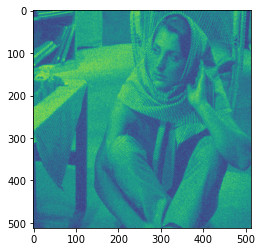

In [130]:
plt.imshow(circshift(img_noise,delta[2,:]))

In [110]:
n = gray.shape[0]
fTI = zeros([n,n])
T = 3*sigma
for i in arange(0,m*m):
    fS = circshift(img_noise,delta[i,:])
    a = perform_wavortho_transf(fS,Jmin,1,h)
    aT = thresh_hard(a,T)
    fS = perform_wavortho_transf(aT,Jmin,-1,h)
    fS = circshift(fS,-delta[i,:])
    fTI = i/(i+1.0)*fTI + 1.0/(i+1)*fS

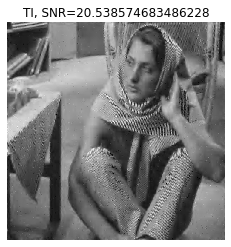

In [111]:
imageplot(clamp(fTI), 'TI, SNR=' + str(snr(gray,fTI)) )
